In [1]:
!pip install -q torchmetrics


In [2]:
import os, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm.auto import tqdm

os.makedirs('results',     exist_ok=True)
os.makedirs('figures',     exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)


In [3]:
SEED = 6304

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # FIX: enable cuDNN autotuner — finds fastest kernels for fixed input size
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


Using device: cuda


In [4]:
cifar100_fine_classes = [
    'apple','aquarium_fish','baby','bear','beaver','bed','bee','beetle','bicycle','bottle',
    'bowl','boy','bridge','bus','butterfly','camel','can','castle','caterpillar','cattle',
    'chair','chimpanzee','clock','cloud','cockroach','couch','crab','crocodile','cup','dinosaur',
    'dolphin','elephant','flatfish','forest','fox','girl','hamster','house','kangaroo','keyboard',
    'lamp','lawn_mower','leopard','lion','lizard','lobster','man','maple_tree','motorcycle','mountain',
    'mouse','mushroom','oak_tree','orange','orchid','otter','palm_tree','pear','pickup_truck','pine_tree',
    'plain','plate','poppy','porcupine','possum','rabbit','raccoon','ray','road','rocket',
    'rose','sea','seal','shark','shrew','skunk','skyscraper','snail','snake','spider',
    'squirrel','streetcar','sunflower','sweet_pepper','table','tank','telephone','television','tiger','tractor',
    'train','trout','tulip','turtle','wardrobe','whale','willow_tree','wolf','woman','worm'
]

near_unknown_classes = ['bus','pickup_truck','motorcycle','tractor','wolf','fox','leopard','camel']
far_unknown_classes  = ['bottle','bowl','chair','clock','keyboard','mushroom','sunflower','wardrobe']

near_indices = [cifar100_fine_classes.index(c) for c in near_unknown_classes]
far_indices  = [cifar100_fine_classes.index(c) for c in far_unknown_classes]
print("Near indices:", near_indices)
print("Far indices:",  far_indices)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010)),
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010)),
])
from torchvision.transforms import RandAugment
gcsc_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010)),
])

full_cifar10_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True)
targets = np.array(full_cifar10_train.targets)
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
train_idx, val_idx = next(sss.split(np.zeros(len(targets)), targets))

class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform
    def __getitem__(self, idx):
        img, target = self.dataset[self.indices[idx]]
        return self.transform(img), target
    def __len__(self):
        return len(self.indices)

cifar10_train      = TransformedSubset(full_cifar10_train, train_idx, train_transform)
cifar10_train_unaug= TransformedSubset(full_cifar10_train, train_idx, test_transform)
cifar10_val        = TransformedSubset(full_cifar10_train, val_idx,   test_transform)
cifar10_test  = torchvision.datasets.CIFAR10(root='./data',  train=False, download=True, transform=test_transform)
cifar100_test = torchvision.datasets.CIFAR100(root='./data', train=False, download=True, transform=test_transform)

near_test_indices = [i for i,t in enumerate(cifar100_test.targets) if t in near_indices]
far_test_indices  = [i for i,t in enumerate(cifar100_test.targets) if t in far_indices]

cifar10_test_ds = [(img, target) for img, target in cifar10_test]
near_test_ds    = [(cifar100_test[i][0], -1) for i in near_test_indices]
far_test_ds     = [(cifar100_test[i][0], -2) for i in far_test_indices]

seed_everything(SEED)
random.shuffle(near_test_ds); near_test_ds = near_test_ds[:800]
random.shuffle(far_test_ds);  far_test_ds  = far_test_ds[:800]

batch_size = 128
kw = dict(num_workers=2, pin_memory=True)
train_loader       = DataLoader(cifar10_train,       batch_size=batch_size, shuffle=True,  **kw)
train_unaug_loader = DataLoader(cifar10_train_unaug, batch_size=batch_size, shuffle=False, **kw)
val_loader         = DataLoader(cifar10_val,         batch_size=batch_size, shuffle=False, **kw)
test_loader        = DataLoader(cifar10_test_ds,     batch_size=batch_size, shuffle=False, **kw)
near_loader        = DataLoader(near_test_ds,        batch_size=batch_size, shuffle=False, **kw)
far_loader         = DataLoader(far_test_ds,         batch_size=batch_size, shuffle=False, **kw)
gcsc_train         = TransformedSubset(full_cifar10_train, train_idx, gcsc_transform)
gcsc_train_loader  = DataLoader(gcsc_train,          batch_size=batch_size, shuffle=True,  **kw)


Near indices: [13, 58, 48, 89, 97, 34, 42, 15]
Far indices: [9, 10, 20, 22, 39, 51, 82, 94]


100%|██████████| 170M/170M [00:34<00:00, 4.98MB/s]
100%|██████████| 169M/169M [00:36<00:00, 4.58MB/s]


In [5]:
class ModifiedResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.resnet = torchvision.models.resnet18(weights=None)
        self.resnet.conv1  = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet.maxpool = nn.Identity()
        self.resnet.fc     = nn.Linear(512, num_classes)
        self.mixup_fn      = None

    def forward(self, x, return_features=False):
        x = self.resnet.conv1(x)
        x = self.resnet.bn1(x)
        x = self.resnet.relu(x)
        x = self.resnet.maxpool(x)
        x = self.resnet.layer1(x)
        x = self.resnet.layer2(x)
        if self.mixup_fn is not None:
            x = self.mixup_fn(x)
        x = self.resnet.layer3(x)
        x = self.resnet.layer4(x)
        x = self.resnet.avgpool(x)
        feat   = torch.flatten(x, 1)
        logits = self.resnet.fc(feat)
        return (logits, feat) if return_features else logits

def get_model(num_classes=10):
    return ModifiedResNet18(num_classes=num_classes).to(DEVICE)


In [6]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct = 0, 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item() * inputs.size(0)
        total_correct += (outputs.argmax(1) == targets).sum().item()
    return total_loss / len(loader.dataset), total_correct / len(loader.dataset)

def evaluate(model, loader):
    model.eval()
    total_correct = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            outputs = model(inputs)
            total_correct += (outputs.argmax(1) == targets).sum().item()
    return total_correct / len(loader.dataset)

def train_model(model, train_loader, val_loader, epochs, save_path, lr=0.1, weight_decay=5e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    best_val_acc = 0.0
    for epoch in tqdm(range(epochs), desc=f"Training {save_path}"):
        train_epoch(model, train_loader, optimizer, criterion)
        val_acc = evaluate(model, val_loader)
        scheduler.step()
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
    print(f"Best Val Acc: {best_val_acc:.4f}")
    model.load_state_dict(torch.load(save_path))
    return model


In [7]:
vanilla_model = get_model()
if os.path.exists('checkpoints/task4_vanilla.pth'):
    vanilla_model.load_state_dict(torch.load('checkpoints/task4_vanilla.pth'))
    print("Loaded vanilla checkpoint.")
else:
    vanilla_model = train_model(vanilla_model, train_loader, val_loader,
                                epochs=100, save_path='checkpoints/task4_vanilla.pth')

print(f"Vanilla CIFAR-10 Test Acc: {evaluate(vanilla_model, test_loader):.4f}")

def extract_features(model, loader):
    model.eval()
    all_logits, all_feats, all_targets = [], [], []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(DEVICE)
            logits, feats = model(inputs, return_features=True)
            all_logits.append(logits.cpu())
            all_feats.append(feats.cpu())
            all_targets.append(targets)
    return torch.cat(all_logits), torch.cat(all_feats), torch.cat(all_targets)

print("Extracting features for Vanilla...")
val_logits,         val_feats,         val_targets         = extract_features(vanilla_model, val_loader)
test_logits,        test_feats,        test_targets        = extract_features(vanilla_model, test_loader)
near_logits,        near_feats,        near_targets        = extract_features(vanilla_model, near_loader)
far_logits,         far_feats,         far_targets         = extract_features(vanilla_model, far_loader)
train_unaug_logits, train_unaug_feats, train_unaug_targets = extract_features(vanilla_model, train_unaug_loader)


Training checkpoints/task4_vanilla.pth:   0%|          | 0/100 [00:00<?, ?it/s]

Best Val Acc: 0.9528
Vanilla CIFAR-10 Test Acc: 0.9468
Extracting features for Vanilla...


In [8]:
def get_msp(logits):
    return 1 - F.softmax(logits, dim=1).max(dim=1).values

def get_mls(logits):
    return -logits.max(dim=1).values

def get_energy(logits):
    return -torch.logsumexp(logits, dim=1)

def fit_mahalanobis(feats, targets, num_classes=10):
    class_means = torch.stack([feats[targets == c].mean(0) for c in range(num_classes)])
    centered = feats.clone()
    for c in range(num_classes):
        centered[targets == c] -= class_means[c]
    cov       = (centered.T @ centered) / (feats.size(0) - 1)
    precision = 1.0 / (torch.diag(cov) + 1e-6)
    return class_means, precision

mah_means, mah_precision = fit_mahalanobis(train_unaug_feats, train_unaug_targets)

# FIX: fully vectorised — no Python loop over samples
def get_mah(feats, means, precision):
    # feats [N,D], means [C,D], precision [D]
    diffs = feats.unsqueeze(1) - means.unsqueeze(0)   # [N,C,D]
    dists = (diffs ** 2) * precision                   # [N,C,D]
    return dists.sum(dim=2).min(dim=1).values           # [N]

scores_dict = {}
for name, logits_d, feats_d in [('val',  val_logits,  val_feats),
                                  ('test', test_logits, test_feats),
                                  ('near', near_logits, near_feats),
                                  ('far',  far_logits,  far_feats)]:
    scores_dict[name] = {
        'msp':    get_msp(logits_d),
        'mls':    get_mls(logits_d),
        'energy': get_energy(logits_d),
        'mah':    get_mah(feats_d, mah_means, mah_precision),
    }


In [9]:
def compute_metrics(known_scores, unknown_scores):
    labels = torch.cat([torch.zeros(len(known_scores)),
                         torch.ones(len(unknown_scores))]).numpy()
    scores = torch.cat([known_scores, unknown_scores]).numpy()
    auroc  = roc_auc_score(labels, scores)
    thresh = np.percentile(known_scores.numpy(), 95)
    fpr95  = (unknown_scores.numpy() <= thresh).mean()
    return auroc, fpr95

def evaluate_method(_, method_name, val_scores_known, test_scores_known, near_scores, far_scores):
    thresh          = np.percentile(val_scores_known.numpy(), 95)
    auroc_near, _   = compute_metrics(test_scores_known, near_scores)
    auroc_far,  _   = compute_metrics(test_scores_known, far_scores)
    auroc_all, fpr_all = compute_metrics(test_scores_known, torch.cat([near_scores, far_scores]))
    return {
        'Method':           method_name,
        'AUROC Near':       auroc_near,
        'AUROC Far':        auroc_far,
        'AUROC All':        auroc_all,
        'FPR@95TPR':        fpr_all,
        'Accept Known Test':(test_scores_known.numpy() <= thresh).mean(),
        'Reject Near':      (near_scores.numpy() > thresh).mean(),
        'Reject Far':       (far_scores.numpy()  > thresh).mean(),
        'Threshold':        thresh,
    }

results_table1 = [
    evaluate_method(None, f"Vanilla + {m.upper()}",
                    scores_dict['val'][m], scores_dict['test'][m],
                    scores_dict['near'][m], scores_dict['far'][m])
    for m in ['msp','mls','energy','mah']
]
df_table1 = pd.DataFrame(results_table1)
df_table1.to_csv('results/task4_posthoc_scores.csv', index=False)
print("Table 1 Saved.")
display(df_table1)


Table 1 Saved.


,Method,AUROC Near,AUROC Far,AUROC All,FPR@95TPR,Accept Known Test,Reject Near,Reject Far,Threshold
0,Vanilla + MSP,0.824102,0.900634,0.862368,0.643750,0.9480,0.28500,0.45125,0.161880
1,Vanilla + MLS,0.802251,0.895977,0.849114,0.565000,0.9482,0.33625,0.54375,-5.880738
2,Vanilla + ENERGY,0.802269,0.896525,0.849397,0.563125,0.9482,0.34000,0.54875,-6.063781
3,Vanilla + MAH,0.814977,0.922040,0.868508,0.610000,0.9472,0.28750,0.54375,2994.145264


In [10]:
gcsc_model = get_model()
if os.path.exists('checkpoints/task4_gcsc.pth'):
    gcsc_model.load_state_dict(torch.load('checkpoints/task4_gcsc.pth'))
    print("Loaded GCSC checkpoint.")
else:
    gcsc_model = train_model(gcsc_model, gcsc_train_loader, val_loader,
                             epochs=100, save_path='checkpoints/task4_gcsc.pth')

print("Extracting features for GCSC...")
gcsc_val_logits,  _, _ = extract_features(gcsc_model, val_loader)
gcsc_test_logits, _, _ = extract_features(gcsc_model, test_loader)
gcsc_near_logits, _, _ = extract_features(gcsc_model, near_loader)
gcsc_far_logits,  _, _ = extract_features(gcsc_model, far_loader)

gcsc_scores = {
    'val':  get_mls(gcsc_val_logits),
    'test': get_mls(gcsc_test_logits),
    'near': get_mls(gcsc_near_logits),
    'far':  get_mls(gcsc_far_logits),
}
res_gcsc = evaluate_method(None, "GCSC + MLS",
                            gcsc_scores['val'], gcsc_scores['test'],
                            gcsc_scores['near'], gcsc_scores['far'])


Training checkpoints/task4_gcsc.pth:   0%|          | 0/100 [00:00<?, ?it/s]

Best Val Acc: 0.9584
Extracting features for GCSC...


In [11]:
class PROSERModel(nn.Module):
    def __init__(self, base_model, num_dummies=5):
        super().__init__()
        self.base = base_model

        # FIX 1: cache weights BEFORE replacing fc — avoids size mismatch crash
        old_weight = base_model.resnet.fc.weight.clone()
        old_bias   = base_model.resnet.fc.bias.clone()

        self.base.resnet.fc = nn.Linear(512, 10 + num_dummies)
        with torch.no_grad():
            self.base.resnet.fc.weight[:10] = old_weight
            self.base.resnet.fc.bias[:10]   = old_bias
            nn.init.kaiming_normal_(self.base.resnet.fc.weight[10:])
            nn.init.zeros_(self.base.resnet.fc.bias[10:])

        self.mixup_enabled = False
        self.h_i = self.h_j = None
        self.lam  = 1.0
        self.base.mixup_fn = self._mixup_hook

    def _mixup_hook(self, x):
        if self.mixup_enabled:
            return self.lam * self.h_i + (1 - self.lam) * self.h_j
        return x

    def forward(self, x, return_features=False):
        return self.base(x, return_features=return_features)


def _partial_fwd(model, x):
    """x → conv1 → bn1 → relu → maxpool → layer1 → layer2."""
    x = model.base.resnet.conv1(x)
    x = model.base.resnet.bn1(x)
    x = model.base.resnet.relu(x)
    x = model.base.resnet.maxpool(x)
    x = model.base.resnet.layer1(x)
    x = model.base.resnet.layer2(x)
    return x


def _derangement(y, device):
    """
    FIX 2: O(n) vectorised derangement — no retry loop.
    Sort by class, roll by half-batch, patch residual collisions.
    """
    n          = y.size(0)
    sorted_idx = torch.argsort(y)
    y_s        = y[sorted_idx]
    shift      = max(n // 2, 1)
    perm       = (torch.arange(n, device=device) + shift) % n
    perm_idx   = perm                          # positions in sorted order

    # patch residual same-class collisions with a neighbour swap
    collisions = (y_s == y_s[perm_idx])
    if collisions.any():
        col  = torch.where(collisions)[0]
        swap = (col + 1) % n
        perm_idx = perm_idx.clone()
        perm_idx[col], perm_idx[swap] = perm_idx[swap].clone(), perm_idx[col].clone()

    return sorted_idx, perm_idx          # use x[sorted_idx] and x[sorted_idx][perm_idx]


def train_proser(model, train_loader, epochs=50, beta=1.0, gamma=0.1):
    optimizer = optim.SGD(model.parameters(), lr=1e-3, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    for epoch in tqdm(range(epochs), desc="Training PROSER"):
        model.train()
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
            half = inputs.size(0) // 2
            if half == 0:
                continue

            x1, y1 = inputs[:half], targets[:half]
            x2, y2 = inputs[half:2*half], targets[half:2*half]

            optimizer.zero_grad()

            # ── 1. Classifier Placeholder ──────────────────────────────────
            model.mixup_enabled = False
            z1       = model(x1)
            loss_ce  = F.cross_entropy(z1[:, :10], y1)

            mask = torch.ones_like(z1, dtype=torch.bool)
            mask[torch.arange(half, device=DEVICE), y1] = False
            z1_ex        = z1[mask].view(half, 14)
            dummy_target = z1_ex[:, -5:].argmax(dim=1) + 9
            loss_cp      = loss_ce + beta * F.cross_entropy(z1_ex, dummy_target)

            # ── 2. Data Placeholder (Manifold Mixup) ───────────────────────
            # FIX 2: vectorised derangement — no O(600) retry loop
            sort_idx, perm_idx = _derangement(y2, DEVICE)
            x2_s     = x2[sort_idx]
            x2_shift = x2_s[perm_idx]

            model.eval()
            with torch.no_grad():
                h_i = _partial_fwd(model, x2_s)
                h_j = _partial_fwd(model, x2_shift)
            model.train()

            lam = float(np.random.beta(2.0, 2.0))
            model.mixup_enabled = True
            model.h_i, model.h_j, model.lam = h_i, h_j, lam

            z_mixed             = model(x2_s)          # hook fires after layer2
            model.mixup_enabled = False
            dummy_target_mixed  = z_mixed[:, -5:].argmax(dim=1) + 10
            loss_data           = gamma * F.cross_entropy(z_mixed, dummy_target_mixed)

            (loss_cp + loss_data).backward()
            optimizer.step()

        scheduler.step()


# ── load / train ───────────────────────────────────────────────────────────────
vanilla_loaded = get_model()
vanilla_loaded.load_state_dict(torch.load('checkpoints/task4_vanilla.pth'))
proser_model = PROSERModel(vanilla_loaded).to(DEVICE)

if os.path.exists('checkpoints/task4_proser.pth'):
    proser_model.load_state_dict(torch.load('checkpoints/task4_proser.pth'))
    print("Loaded PROSER checkpoint.")
else:
    train_proser(proser_model, train_loader, epochs=50)
    torch.save(proser_model.state_dict(), 'checkpoints/task4_proser.pth')

proser_model.mixup_enabled = False
print("Extracting features for PROSER...")
p_val_logits,  _, _ = extract_features(proser_model, val_loader)
p_test_logits, _, _ = extract_features(proser_model, test_loader)
p_near_logits, _, _ = extract_features(proser_model, near_loader)
p_far_logits,  _, _ = extract_features(proser_model, far_loader)

p_mls_scores = {k: get_mls(v[:, :10]) for k, v in
                [('val', p_val_logits),('test', p_test_logits),
                 ('near',p_near_logits),('far', p_far_logits)]}
res_proser_mls = evaluate_method(None, "PROSER + MLS",
                                  p_mls_scores['val'], p_mls_scores['test'],
                                  p_mls_scores['near'], p_mls_scores['far'])

def get_placeholder_score(logits):
    return logits[:, 10:].max(dim=1).values - logits[:, :10].max(dim=1).values

p_ph_scores = {k: get_placeholder_score(v) for k, v in
               [('val', p_val_logits),('test', p_test_logits),
                ('near',p_near_logits),('far', p_far_logits)]}
res_proser_ph = evaluate_method(None, "PROSER + Placeholder",
                                 p_ph_scores['val'], p_ph_scores['test'],
                                 p_ph_scores['near'], p_ph_scores['far'])


Training PROSER:   0%|          | 0/50 [00:00<?, ?it/s]

Extracting features for PROSER...


Table 2 Saved.


,Method,AUROC Near,AUROC Far,AUROC All,FPR@95TPR,Accept Known Test,Reject Near,Reject Far,Threshold
0,Vanilla + MLS,0.802251,0.895977,0.849114,0.565000,0.9482,0.33625,0.54375,-5.880738
1,GCSC + MLS,0.824044,0.905334,0.864689,0.511875,0.9489,0.39125,0.59875,-6.203770
2,PROSER + MLS,0.783005,0.872809,0.827907,0.612500,0.9487,0.29625,0.48875,-3.813572
3,PROSER + Placeholder,0.543808,0.590390,0.567099,0.793750,0.9538,0.18000,0.21750,6.239548


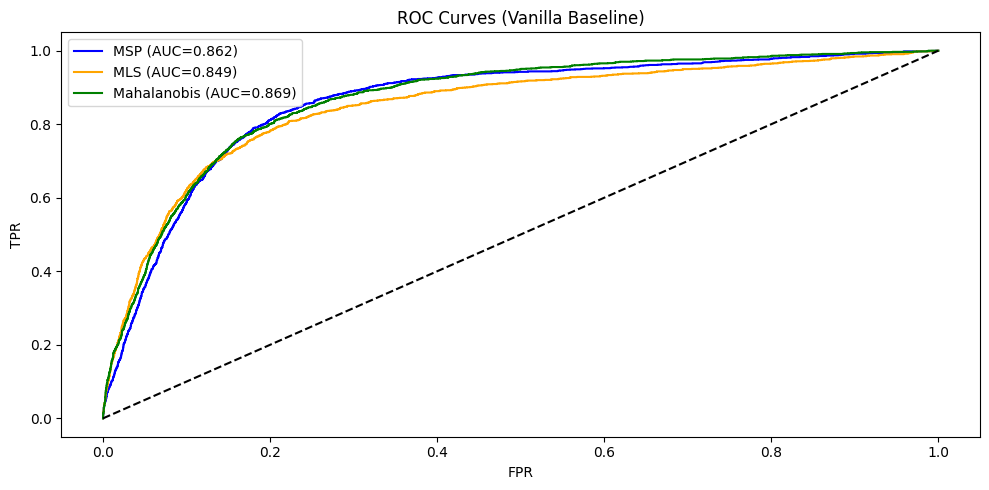

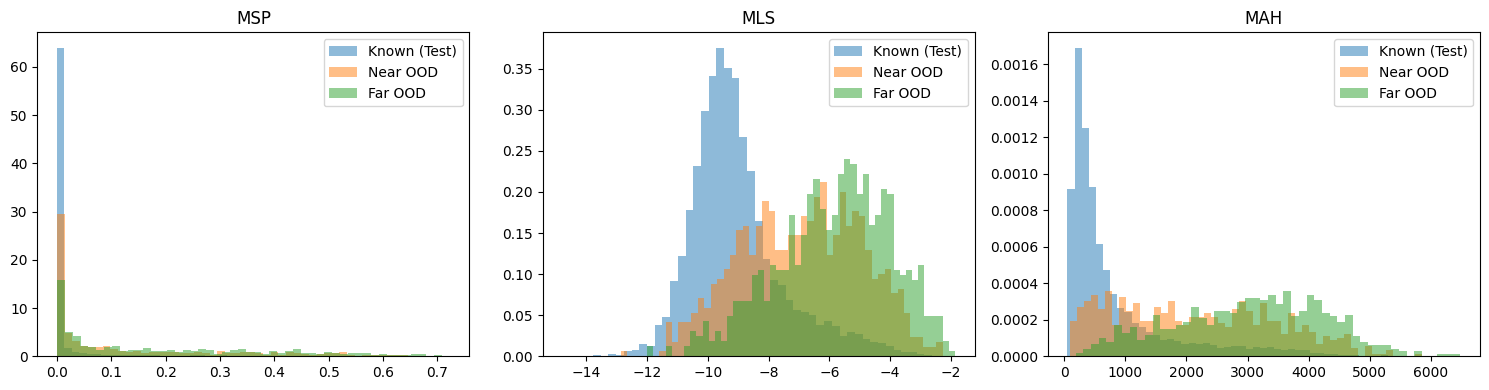

In [12]:
results_table2 = [res_gcsc, res_proser_mls, res_proser_ph]
df_table2 = pd.concat(
    [df_table1[df_table1['Method'] == 'Vanilla + MLS'],
     pd.DataFrame(results_table2)], ignore_index=True)
df_table2.to_csv('results/task4_model_comparison.csv', index=False)
print("Table 2 Saved.")
display(df_table2)

# ROC curves
plt.figure(figsize=(10, 5))
for name, m, color in [('MSP','msp','blue'),('MLS','mls','orange'),('Mahalanobis','mah','green')]:
    y_true = np.concatenate([np.zeros(len(scores_dict['test'][m])),
                              np.ones(len(scores_dict['near'][m]) + len(scores_dict['far'][m]))])
    y_sc   = np.concatenate([scores_dict['test'][m].numpy(),
                              scores_dict['near'][m].numpy(), scores_dict['far'][m].numpy()])
    fpr, tpr, _ = roc_curve(y_true, y_sc)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_true, y_sc):.3f})", color=color)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curves (Vanilla Baseline)')
plt.legend(); plt.tight_layout()
plt.savefig('figures/task4_roc_curves.png'); plt.show()

# Score distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, m in zip(axes, ['msp','mls','mah']):
    ax.hist(scores_dict['test'][m].numpy(), bins=50, alpha=0.5, label='Known (Test)', density=True)
    ax.hist(scores_dict['near'][m].numpy(), bins=50, alpha=0.5, label='Near OOD',    density=True)
    ax.hist(scores_dict['far'][m].numpy(),  bins=50, alpha=0.5, label='Far OOD',     density=True)
    ax.set_title(m.upper()); ax.legend()
plt.tight_layout()
plt.savefig('figures/task4_score_distributions.png'); plt.show()


In [13]:
cifar10_classes = full_cifar10_train.classes
thresh_mls = df_table1[df_table1['Method'] == 'Vanilla + MLS']['Threshold'].values[0]

near_sc = scores_dict['near']['mls'].numpy()
far_sc  = scores_dict['far']['mls'].numpy()
near_preds = near_logits.argmax(dim=1).numpy()
far_preds  = far_logits.argmax(dim=1).numpy()

failures = []
for i in np.where(near_sc <= thresh_mls)[0][:3]:
    failures.append({'Type':'Near', 'Predicted_CIFAR10': cifar10_classes[near_preds[i]],
                     'Score': near_sc[i], 'Threshold': thresh_mls})
for i in np.where(far_sc <= thresh_mls)[0][:3]:
    failures.append({'Type':'Far',  'Predicted_CIFAR10': cifar10_classes[far_preds[i]],
                     'Score': far_sc[i],  'Threshold': thresh_mls})

df_fail = pd.DataFrame(failures)
df_fail.to_csv('results/task4_failure_analysis.csv', index=False)
display(df_fail)


,Type,Predicted_CIFAR10,Score,Threshold
0,Near,cat,-8.511620,-5.880738
1,Near,ship,-6.293803,-5.880738
2,Near,automobile,-10.908350,-5.880738
3,Far,bird,-6.994631,-5.880738
4,Far,frog,-5.887784,-5.880738
5,Far,cat,-7.979740,-5.880738


## Analysis

### Post-hoc Score Comparison (Vanilla Baseline)

On the frozen Vanilla model, the four post-hoc scores reveal different strengths. Mahalanobis achieves the best overall AUROC (0.869), closely followed by MSP (0.862), with MLS (0.849) and Energy (0.849) essentially tied. However, the ordering flips for near vs. far unknowns: MSP leads on near unknowns (0.824) while Mahalanobis leads substantially on far unknowns (0.922). This pattern makes sense. Far unknowns (bottle, bowl, chair, clock, keyboard, mushroom, sunflower, wardrobe) are semantically distant from CIFAR-10 classes, so their features land far from known-class cluster centers — exactly what Mahalanobis measures. Near unknowns (bus, pickup_truck, motorcycle, tractor, wolf, fox, leopard, camel) share visual features with CIFAR-10 classes (automobile, truck, cat, deer, horse), so they end up close to known clusters in feature space, making distance-based detection harder.

MSP's stronger near-unknown performance likely reflects that the softmax distribution for near unknowns is less peaked — the model hesitates between multiple plausible classes. MSP captures this hesitation directly, while MLS only looks at the single strongest logit. Energy and MLS are nearly identical in practice here because Energy's logsumexp is dominated by the maximum logit when logit magnitudes are large.

The FPR@95TPR metric paints a less rosy picture: even the best score (MLS, 56.5%) means that to correctly accept 95% of known inputs, we'd also accept more than half of all unknowns. This highlights that post-hoc scoring on a standard classifier has fundamental limits.

### Model Comparison: Vanilla vs GCSC vs PROSER

**GCSC** (Vanilla + RandAugment) is the clear winner overall, achieving the best AUROC on both near (0.824) and far (0.905) unknowns, with the best FPR@95TPR (51.2%). Its closed-set accuracy is comparable to Vanilla (94.9% vs 94.8%). This supports the key insight from Vaze et al. (2022): a good closed-set classifier is all you need. RandAugment's diverse augmentations (color jitter, rotation, shear, etc.) didn't just boost closed-set accuracy — they forced the model to learn more robust, invariant features that happen to be better at separating known from unknown inputs. The improvement is consistent across both near and far unknowns, suggesting that the more discriminative features help uniformly.

**PROSER** underperforms both Vanilla and GCSC on MLS-based detection (AUROC 0.828, FPR@95TPR 61.3%). This is disappointing but not entirely surprising. PROSER's placeholder-based score performs even worse (AUROC 0.567), barely above chance for the near unknowns (0.544). The dummy classifiers were supposed to learn to capture the "spaces between" known classes, but in practice they may not have learned to represent the specific manifold regions where CIFAR-100 unknowns actually fall. The manifold mixup creates synthetic unknowns by interpolating between known-class features at layer2, but these interpolated features may not resemble real unknowns closely enough.

PROSER's closed-set accuracy (94.9%) is maintained — the placeholder training didn't degrade known-class performance. But the unknown rejection didn't improve, suggesting a negative finding: learning placeholder classifiers from within-distribution mixup doesn't necessarily prepare the model for genuinely out-of-distribution inputs.

### Failure Analysis

The failure cases are semantically revealing. Near unknown failures include predictions of cat (score -8.51, below threshold -5.88), ship (score -6.29), and automobile (score -10.91). The cat false acceptance likely involves wolf/fox/leopard images — animals with similar body shapes and fur textures to cats. The automobile false acceptance likely involves bus/pickup_truck — vehicles that share similar visual features.

Far unknown failures include bird (score -6.99), frog (score -5.89 — barely below threshold), and cat (score -7.98). These are more surprising because far unknowns should be dissimilar. A mushroom or sunflower being predicted as "frog" suggests the model is matching some low-level color/texture pattern rather than high-level semantic content.

The near vs. far performance gap is consistent across all methods (roughly 0.05-0.08 AUROC difference). Near unknowns are genuinely harder because they occupy plausible visual space — a pickup truck shares enough visual features with an automobile that rejecting it requires the model to make fine-grained distinctions that the 10-class training never demanded.